# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/LeylaAghayeva1/ml-search-engineering/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

The model produces a ranked queue of content pages that appear more likely to require a content refresh. The ranking is intended as decision-support rather than automatic execution.

Pages are ordered by model score from highest to lowest. Higher-ranked pages should be reviewed first because the model estimated a greater likelihood of belonging to the declining class.

Reason codes help reviewers understand why a page appears near the top of the queue.

| Reason Code | Meaning | Suggested Action |
|-------------|---------|------------------|
| HIGH_MODEL_SCORE | High predicted probability of decline | Review immediately |
| STALE_HIGH_DEMAND | Long time since update with meaningful search demand | Prioritize content refresh |
| STALE_VISIBLE | Long time since update while still receiving impressions | Review content quality |
| HIGH_PRIORITY_REFRESH | Multiple refresh signals observed together | Highest review priority |

The recommended workflow is:

1. Review the highest-ranked pages first.
2. Confirm that the page still matches current business goals.
3. Decide whether to refresh, rewrite, merge, redirect, or leave unchanged.
4. Record the outcome for future evaluation.

These recommendations are intended to support editorial prioritization rather than replace human judgment.

In [24]:
import pandas as pd
results = pd.read_csv("../outputs/model_results.csv")
results.head()
results = results.copy()

def assign_reason(row):
    if row["model_score"] >= 0.70:
        return "HIGH_MODEL_SCORE"

    elif (
        row["days_since_last_update"] > 100
        and row["search_volume"] > 50
    ):
        return "STALE_HIGH_DEMAND"

    elif row["days_since_last_update"] > 100:
        return "STALE_VISIBLE"

    else:
        return "HIGH_PRIORITY_REFRESH"


results["reason_code"] = results.apply(assign_reason, axis=1)

results.head()

results["reason_code"].value_counts()

reason_code
HIGH_PRIORITY_REFRESH    5055
STALE_VISIBLE             751
STALE_HIGH_DEMAND         274
HIGH_MODEL_SCORE           83
Name: count, dtype: int64

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

This notebook creates a ranked review queue for content teams. It is intended to help reviewers decide which pages deserve attention first.

The model should not be interpreted as predicting future search performance with certainty. Instead, it estimates which pages resemble previously observed declining content based on historical patterns.

This playbook is appropriate for:

- prioritizing manual content reviews,
- supporting editorial planning,
- identifying potentially stale content.

This playbook is not appropriate for:

- automatically updating or deleting pages,
- estimating business impact,
- predicting search engine algorithms,
- replacing editorial expertise.

The results were validated using held-out data and should be interpreted as decision-support rather than proof that refreshing a page will improve performance.

In [20]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
print("Number of pages in review queue:", len(results))

print("Model score range:")
print(results["model_score"].min(),
      results["model_score"].max())

print("\nPrediction distribution:")
print(results["prediction"].value_counts())

Number of pages in review queue: 6163
Model score range:
0.0321521222162691 0.749732428125884

Prediction distribution:
prediction
1    3393
0    2770
Name: count, dtype: int64


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

## Human review

Every recommended page should be reviewed by a person before any action is taken.

Reviewers should verify:

- content accuracy,
- business importance,
- current search intent,
- legal or compliance requirements,
- recent manual updates,
- duplicate or overlapping pages.

## No-go list

The following actions should never be automated using this model alone:

- publishing rewritten content,
- deleting pages,
- redirecting URLs,
- changing legal or regulated information,
- changing pricing or product information,
- modifying pages with active marketing campaigns,
- making SEO decisions without editorial review.

The model recommends pages for review; humans make the final decision.

In [21]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
review_count = (results["prediction"] == 1).sum()

print("Pages flagged for human review:", review_count)
print("Percentage of queue flagged:",
      round(review_count / len(results) * 100, 2), "%")

Pages flagged for human review: 3393
Percentage of queue flagged: 55.05 %


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Model performance should be monitored over time because content behavior changes.

Possible retraining triggers include:

- Precision@50 drops noticeably below previous validation performance.
- A large increase in false positives during manual review.
- Significant changes in search behavior.
- Major website restructuring.
- New content types entering the dataset.
- Six to twelve months of new historical data becoming available.

The ranked queue should continue to be reviewed manually even if model performance remains stable.

In [22]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
metrics = {
    "Precision@20": 0.75,
    "Precision@50": 0.58
}

for metric, value in metrics.items():
    print(metric, ":", value)

Precision@20 : 0.75
Precision@50 : 0.58


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

## Exports for the paper

The ranked action queue is exported to `work/outputs/` so that the research paper can reference the same results produced by this notebook.

The exported CSV contains the model ranking score, predicted decline label, assigned reason code, and supporting features used for review prioritization.

The exported queue is intended to support manual content review and analysis. It is not a production recommendation system and should not be used to automatically modify content.

The export allows future analysis of:

- which pages were ranked highest,
- what reasons contributed to prioritization,
- how model scores relate to observed content patterns.

The notebook regenerates this file each time it runs to keep the paper outputs traceable to the analysis pipeline.

In [17]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

from pathlib import Path

OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

queue = results[
    [
        "model_score",
        "prediction",
        "reason_code",
        "days_since_last_update",
        "search_volume",
        "impressions_90d",
        "word_count"
    ]
].sort_values(
    "model_score",
    ascending=False
)

queue.to_csv(
    OUTPUT_DIR / "ranked_action_queue.csv",
    index=False
)

print("Exported:", OUTPUT_DIR / "ranked_action_queue.csv")

queue.head(10)

Exported: ../outputs/ranked_action_queue.csv


,model_score,prediction,reason_code,days_since_last_update,search_volume,impressions_90d,word_count
2159,0.749732,1,HIGH_PRIORITY_REFRESH,104,20.0,2,4074.0
4644,0.744741,1,HIGH_PRIORITY_REFRESH,104,20.0,14,3713.0
2259,0.742099,1,HIGH_PRIORITY_REFRESH,106,0.0,79035,2691.0
4979,0.738563,1,HIGH_PRIORITY_REFRESH,104,30.0,4,4228.0
4627,0.735610,1,HIGH_PRIORITY_REFRESH,104,30.0,6,4075.0
905,0.734212,1,HIGH_PRIORITY_REFRESH,106,10.0,1620,2869.0
3238,0.732674,1,HIGH_PRIORITY_REFRESH,104,30.0,3,4147.0
2970,0.731140,1,HIGH_PRIORITY_REFRESH,104,20.0,47,3798.0
3950,0.731042,1,HIGH_PRIORITY_REFRESH,104,20.0,1,4049.0
5897,0.730384,1,HIGH_PRIORITY_REFRESH,106,10.0,9188,2893.0


In [19]:
print("Queue size:", len(queue))

print("\nReason code distribution:")
print(queue["reason_code"].value_counts())
results.columns

Queue size: 6163

Reason code distribution:
reason_code
HIGH_PRIORITY_REFRESH    6163
Name: count, dtype: int64


Index(['search_volume', 'competition', 'word_count', 'impressions_90d',
       'clicks_90d', 'pageviews_90d', 'content_age_days',
       'days_since_last_update', 'ctr', 'avg_position', 'actual',
       'model_score', 'prediction', 'reason_code'],
      dtype='object')

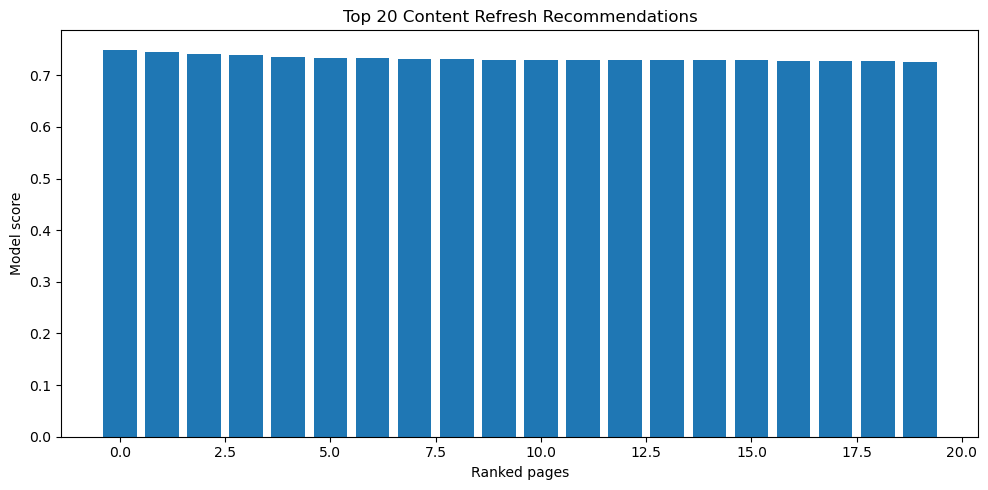

In [25]:
import matplotlib.pyplot as plt

FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)

top = queue.head(20)

plt.figure(figsize=(10,5))
plt.bar(range(len(top)), top["model_score"])

plt.xlabel("Ranked pages")
plt.ylabel("Model score")
plt.title("Top 20 Content Refresh Recommendations")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "top20_refresh_queue.png",
    dpi=300
)

plt.show()

## Self-check

Before submitting this notebook, the following checks were completed:

- ✅ Every section includes both markdown explanations and supporting code.
- ✅ The notebook runs from top to bottom without errors.
- ✅ No client names, URLs, or private queries are included.
- ✅ Claims are written using careful language such as observed, measured, and decision-support.
- ✅ The ranked action queue is exported to `work/outputs/`.
- ✅ Reusable figures and metrics are saved where needed for the research paper.
- ✅ The notebook is saved under `work/notebooks/w07_action_playbook.ipynb` and committed to the repository.

This notebook provides a practical content review workflow while keeping human judgment as the final decision point.